## **LangGraph_Workflow Type 4 : Parallel Workflow**

A Parallel Workflow is a process where multiple tasks run at the same time (simultaneously) instead of one after another.

👉 It improves speed and efficiency

👉 Independent tasks are executed in parallel branches

👉 Results are later combined (merged) to produce the final output

In [89]:
!pip install langchain langgraph langchain_google_genai

In [90]:
from typing import TypedDict
from langgraph.graph import StateGraph, START,END

## ***Step 1 : Create a state Schema***
- Using PyDantic/TypeDict : Mostly we are using Pydantic: Create our own schema using them (Template).

- They define the structure, type, and rules of your state (shared memory) so every node in the graph works consistently and safely.

In [91]:
class Data(TypedDict):
  num1:float
  num2:float
  add_result:float
  sub_result:float
  mul_result:float

## ***Step 2: Create a State Graph Object***

- With the help of state graph object we can able create entire state graph.
- This object will tell how to add nodws, how to add edges so the final graph will be designed

In [92]:
graph = StateGraph(state_schema = Data)

## ***Step 3: Create Graph using Nodes(Steps) and Edges(connection)***

In [93]:
def add(state:Data):
  state["add_result"] = state["num1"] + state["num2"]
  return {"add_result":state["add_result"]} #Only return partial state:Dictionary

In [94]:
def sub(state:Data):
  state["sub_result"] = state["num1"] - state["num2"]
  return {"sub_result":state["sub_result"]}

In [95]:
def mul(state:Data):
  state["mul_result"] = state["num1"] * state["num2"]
  return {"mul_result":state["mul_result"]}

In [96]:
# Add the nodes

graph.add_node("add",add)
graph.add_node("sub",sub)
graph.add_node("mul",mul)

In [97]:
# Add the edges (Parallel Way)
graph.add_edge(START,"add")
graph.add_edge(START,"sub")
graph.add_edge(START,"mul")
graph.add_edge("add",END)
graph.add_edge("sub",END)
graph.add_edge("mul",END)


## ***Step 4 : Compile the graph***

In [98]:
state_graph = graph.compile()

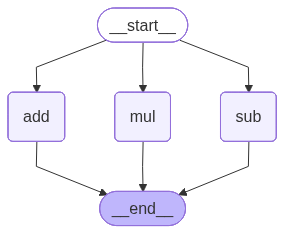

In [99]:
state_graph

In [100]:
state_graph.invoke({"num1":10,"num2":20})

{'num1': 10,
 'num2': 20,
 'add_result': 30,
 'sub_result': -10,
 'mul_result': 200}

In [101]:
state_graph.invoke(Data(num1=10,num2=12))

{'num1': 10, 'num2': 12, 'add_result': 22, 'sub_result': -2, 'mul_result': 120}

## **Reducer**
#### In LangGraph, a reducer is a function used to control how state gets updated when multiple nodes try to modify the same data.

- A function that combines old state + new updates → into a final state


### **Why Reducers Are Needed**

In LangGraph, multiple nodes can run:

- Sequentially
- In parallel

If two nodes update the same variable at the same time, LangGraph needs a rule:

👉 Which value should be kept?

👉 How should they be merged?

That rule is defined using a reducer.

### **Common Reducers: add (Most used)**: Combines lists

- Reducers decide how multiple updates to the same state are combined in LangGraph.


In [102]:
from operator import add #reducers
from typing import Annotated
#1. Create state Schema
# variable: Annotated[datatype, extra_info]

class Data(TypedDict):
  num1:float
  num2:float
  result:Annotated[list[float],add] #Reducers=add (Merge)

In [103]:
# 2.Stage graph object

graph = StateGraph(state_schema = Data)

In [104]:
def add(state:Data):
  return {"result" : [state["num1"] + state["num2"]]}

def sub(state:Data):
  return {"result" : [state["num1"] - state["num2"]]}

def mul(state:Data):
  return {"result" : [state["num1"] * state["num2"]]}

In [105]:
#3. Create nodes and edges
graph.add_node("add",add)
graph.add_node("sub",sub)
graph.add_node("mul",mul)

In [106]:
# Add the edges (Parallel Way)
graph.add_edge(START,"add")
graph.add_edge(START,"sub")
graph.add_edge(START,"mul")
graph.add_edge("add",END)
graph.add_edge("sub",END)
graph.add_edge("mul",END)

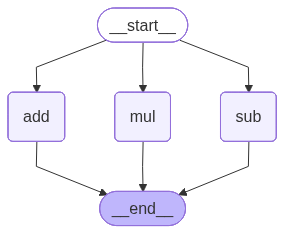

In [107]:
state_graph = graph.compile()
state_graph

In [108]:
state_graph.invoke({"num1":10,"num2":20})

{'num1': 10, 'num2': 20, 'result': [30, 200, -10]}

### ***Step 1 : Understand the Problem Statements:***

- Problem Satement: Create a LangGraph workflow which take topic as an input (e.g Langchain,LLM,Python,RAG) and give 4 Outputs (Basic_Explanation, Advantages, Disadvantage, 10 MCQs)

In [156]:
import os

from google.colab import userdata
gem = userdata.get('gemini')

os.environ["GOOGLE_API_KEY"]=gem

## ***Step 2 : Create a state***

In [169]:
from pydantic import BaseModel,Field

from langgraph.graph import StateGraph, START, END

from typing import Annotated
from operator import add

In [170]:
# Create state schema

class Data(BaseModel):
    topic: str
    result: Annotated[list[str], add] = Field(default_factory=list)

In [171]:
x = Data(topic = "Ai")
x

Data(topic='Ai', result=[])

## ***Step 3: Create a State Graph Object***

In [172]:
# Here we need ChatPromptTemplate, LLM(Model), StrOutput Parser
# Need to design 4 function for (Basic_Explanation, Advantages, Disadvantage, 10 MCQs)

In [173]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate

In [174]:
# Create state Graph object
graph = StateGraph(state_schema=Data)

## ***Step 4: Create Graph using Nodes(Steps) and Edges(connection)***

In [175]:
def basic_explanation(state:Data):
  cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("You are having 10+ years of experience in Data Science and AI industry so give me each and every answer based on given topics"),
                                          HumanMessagePromptTemplate.from_template("Based on this topic:{topic} generate me a 3 lines of basic_explanation")])
  model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
  app = cpt|model

  answer = app.invoke({"topic":state.topic})
  return {"result": [answer.content]}


def advantages(state:Data):
  cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("You are having 10+ years of experience in Data Science and AI industry so give me each and every answer based on given topics"),
                                          HumanMessagePromptTemplate.from_template("Based on this topic:{topic} generate me Advantages of the topic")])
  model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
  app = cpt|model

  answer = app.invoke({"topic":state.topic})
  return {"result": [answer.content]}

def Disadvantages(state:Data):
  cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("You are having 10+ years of experience in Data Science and AI industry so give me each and every answer based on given topics"),
                                          HumanMessagePromptTemplate.from_template("Based on this topic:{topic} generate me Disadvantages of the topic")])
  model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
  app = cpt|model

  answer = app.invoke({"topic":state.topic})
  return {"result": [answer.content]}

def MCQs(state:Data):
  cpt = ChatPromptTemplate.from_messages([SystemMessagePromptTemplate.from_template("You are having 10+ years of experience in Data Science and AI industry so give me each and every answer based on given topics"),
                                          HumanMessagePromptTemplate.from_template("Based on this topic:{topic} generate 10 MCQs of the topic")])
  model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
  app = cpt|model

  answer = app.invoke({"topic":state.topic})
  return {"result": [answer.content]}

In [176]:
# Add the nodes
graph.add_node("basic_explanation",basic_explanation)
graph.add_node("advantages",advantages)
graph.add_node("Disadvantages",Disadvantages)
graph.add_node("MCQs",MCQs)

In [177]:
graph.add_edge(START,"basic_explanation")
graph.add_edge(START,"advantages")
graph.add_edge(START,"Disadvantages")
graph.add_edge(START,"MCQs")
graph.add_edge("basic_explanation",END)
graph.add_edge("advantages",END)
graph.add_edge("Disadvantages",END)
graph.add_edge("MCQs",END)

## ***Step 5 : Compile the graph***

In [178]:
state_graph = graph.compile()

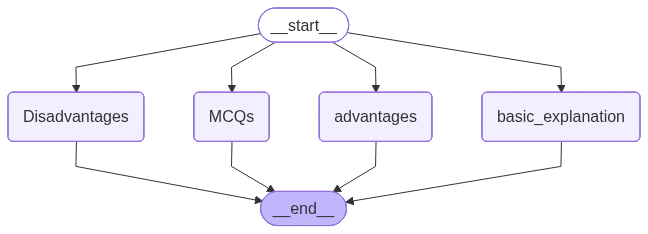

In [179]:
state_graph

In [184]:
data = state_graph.invoke({"topic":"AI"})

In [189]:
print(data["result"][0])

Alright, let's dive into the inherent challenges and potential pitfalls of Artificial Intelligence, from the perspective of someone who's spent over a decade in the trenches, building, deploying, and observing these systems in the real world. While AI offers immense promise, ignoring its disadvantages would be naive and irresponsible.

Here are the key disadvantages of AI, broken down with a professional lens:

1.  **Job Displacement and Socio-Economic Disruption:**
    *   **The Reality:** This isn't just about factory workers; it's about white-collar jobs too. Routine, repetitive tasks across industries – customer service, data entry, certain legal research, financial analysis, even some coding – are highly susceptible to automation.
    *   **Professional Take:** The economic impact will be substantial. We're looking at increased wealth inequality, the obsolescence of entire skill sets, and the need for massive reskilling initiatives. The social safety nets and educational systems i

In [190]:
print(data["result"][1])

Alright, given my extensive background in Data Science and AI, I'll craft 10 MCQs that cover various facets of Artificial Intelligence, from foundational concepts to more nuanced aspects. These questions are designed to test a comprehensive understanding of the field.

---

Here are 10 MCQs on Artificial Intelligence:

---

**1. Which of the following best describes the primary goal of Artificial Intelligence?**
    a) To perfectly replicate human biological intelligence in machines.
    b) To develop machines that can perform tasks requiring human-like intelligence.
    c) To replace all human jobs with automated systems.
    d) To create sentient robots with emotional capabilities.

**Correct Answer:** b) To develop machines that can perform tasks requiring human-like intelligence.
*   **Explanation:** The core aim of AI is to enable machines to simulate cognitive functions typically associated with human minds, such as learning, problem-solving, perception, and decision-making, with

In [191]:
print(data["result"][2])

As someone with over a decade of experience navigating the complexities and opportunities within Data Science and AI, I can confidently say that the advantages of Artificial Intelligence are profound and multifaceted, impacting virtually every sector. Here's a breakdown, framed from a strategic and practical industry perspective:

### Advantages of Artificial Intelligence (AI)

1.  **Enhanced Automation & Operational Efficiency:**
    *   **How AI Helps:** AI excels at automating repetitive, mundane, and rules-based tasks at speed and scale that humans cannot match. This includes data entry, customer service inquiries (chatbots), manufacturing processes (robotics), and back-office operations (RPA with AI).
    *   **Industry Impact:** Significant cost reduction, faster processing times, reduced human error, and the ability to free up human capital for more creative, strategic, and high-value tasks. This directly translates to improved productivity and streamlined operations across the 

In [192]:
print(data["result"][3])

Artificial Intelligence (AI) refers to the development of computer systems capable of performing tasks that typically require human intelligence. These systems learn from data, reason, problem-solve, and understand language or perceive their environment. Its core purpose is to automate complex processes, make informed predictions, and enhance human decision-making across various domains.
